In [2]:
from scipy.io import loadmat
import numpy as np
import os

data = loadmat("C:/Users/Minnie/Desktop/MCI/MCI1/1.mat")
print(data.keys())


dict_keys(['__header__', '__version__', '__globals__', 'export'])


In [3]:
def load_all_mat_from_nested_folders(root_dir, label_value, window=512, stride=256):
    import numpy as np
    import os
    from scipy.io import loadmat

    X_list = []
    print(f"🔍 탐색 시작: {root_dir}")

    for subject in os.listdir(root_dir):
        subject_dir = os.path.join(root_dir, subject)
        if not os.path.isdir(subject_dir):
            continue

        for file in os.listdir(subject_dir):
            if not file.endswith(".mat"):
                continue

            path = os.path.join(subject_dir, file)
            try:
                mat = loadmat(path)
                if 'export' not in mat:
                    print(f"⚠️ 'export' key 없음: {path}")
                    continue

                eeg = mat['export']  # shape: (T, C) or (C, T)

                # 자동 transpose: 채널이 19가 아니면 전치
                if eeg.shape[0] != 19 and eeg.shape[1] == 19:
                    eeg = eeg.T

                ch, t = eeg.shape
                if t < window:
                    print(f"⚠️ 너무 짧은 EEG: {eeg.shape} in {path}")
                    continue

                for start in range(0, t - window + 1, stride):
                    epoch = eeg[:, start:start + window]
                    X_list.append(epoch)

                print(f"✅ 처리됨: {file}, epoch 수: {(t - window) // stride + 1}")

            except Exception as e:
                print(f"❌ 예외 발생: {file} - {e}")

    if len(X_list) == 0:
        raise ValueError(f"❌ 유효한 EEG가 없음: {root_dir}")

    X_arr = np.stack(X_list)
    y_arr = np.full(len(X_arr), label_value)
    print(f"✅ 총 epoch 수: {len(X_arr)} from {root_dir}")
    return X_arr, y_arr


In [4]:
def load_control_data_with_dense_stride(root_dir, label_value=2, window=512, stride=64):


    X_list = []
    print(f"🚀 CONTROL 데이터 강화 시작: {root_dir} (stride={stride})")

    for subject in os.listdir(root_dir):
        subject_dir = os.path.join(root_dir, subject)
        if not os.path.isdir(subject_dir):
            continue

        for file in os.listdir(subject_dir):
            if not file.endswith(".mat"):
                continue

            path = os.path.join(subject_dir, file)
            try:
                mat = loadmat(path)
                if 'export' not in mat:
                    print(f"⚠️ 'export' key 없음: {path}")
                    continue

                eeg = mat['export']

                if eeg.shape[0] != 19 and eeg.shape[1] == 19:
                    eeg = eeg.T  # (채널, 시간)

                ch, t = eeg.shape
                if t < window:
                    continue

                for start in range(0, t - window + 1, stride):
                    epoch = eeg[:, start:start + window]
                    X_list.append(epoch)

            except Exception as e:
                print(f"❌ 파일 오류: {path} - {e}")

    if len(X_list) == 0:
        raise ValueError("❌ CONTROL 데이터를 불러오지 못했습니다.")

    X_arr = np.stack(X_list)
    y_arr = np.full(len(X_arr), label_value)
    print(f"✅ 생성된 CONTROL epoch 수: {len(X_arr)}")
    return X_arr, y_arr


In [5]:
X_ctrl, y_ctrl = load_control_data_with_dense_stride(
    "C:/Users/Minnie/Desktop/CONTROL", label_value=2, window=512, stride=64)


🚀 CONTROL 데이터 강화 시작: C:/Users/Minnie/Desktop/CONTROL (stride=64)
✅ 생성된 CONTROL epoch 수: 941


In [6]:
X_ad, y_ad = load_all_mat_from_nested_folders("C:/Users/Minnie/Desktop/AD", label_value=0)
X_mci, y_mci = load_all_mat_from_nested_folders("C:/Users/Minnie/Desktop/MCI", label_value=1)
X_ctrl, y_ctrl = load_all_mat_from_nested_folders("C:/Users/Minnie/Desktop/CONTROL", label_value=2)

X_all = np.concatenate([X_ad, X_mci, X_ctrl], axis=0)
y_all = np.concatenate([y_ad, y_mci, y_ctrl], axis=0)

print("✅ 전체 EEG shape:", X_all.shape)  # (전체 epoch 수, 19, 512)
print("✅ 라벨 분포:", np.unique(y_all, return_counts=True))



🔍 탐색 시작: C:/Users/Minnie/Desktop/AD
✅ 처리됨: 1.mat, epoch 수: 27
✅ 처리됨: 2.mat, epoch 수: 71
⚠️ 너무 짧은 EEG: (6776, 18) in C:/Users/Minnie/Desktop/AD\AD1\3.mat
✅ 처리됨: 4.mat, epoch 수: 92
✅ 처리됨: 5.mat, epoch 수: 121
✅ 처리됨: 1.mat, epoch 수: 13
✅ 처리됨: 2.mat, epoch 수: 9
✅ 처리됨: 3.mat, epoch 수: 16
✅ 처리됨: 4.mat, epoch 수: 20
✅ 처리됨: 5.mat, epoch 수: 14
✅ 처리됨: 6.mat, epoch 수: 12
✅ 처리됨: 7.mat, epoch 수: 25
✅ 처리됨: 8.mat, epoch 수: 94
✅ 처리됨: 9.mat, epoch 수: 9
✅ 처리됨: 1.mat, epoch 수: 147
✅ 처리됨: 2.mat, epoch 수: 84
✅ 처리됨: 3.mat, epoch 수: 61
✅ 처리됨: 4.mat, epoch 수: 98
✅ 처리됨: 1.mat, epoch 수: 44
✅ 처리됨: 2.mat, epoch 수: 36
✅ 처리됨: 3.mat, epoch 수: 45
✅ 처리됨: 4.mat, epoch 수: 147
✅ 처리됨: 5.mat, epoch 수: 20
✅ 처리됨: 6.mat, epoch 수: 58
✅ 처리됨: 7.mat, epoch 수: 26
✅ 처리됨: 8.mat, epoch 수: 20
✅ 처리됨: 1.mat, epoch 수: 148
✅ 처리됨: 2.mat, epoch 수: 147
✅ 처리됨: 3.mat, epoch 수: 50
✅ 처리됨: 1.mat, epoch 수: 21
✅ 처리됨: 2.mat, epoch 수: 32
✅ 처리됨: 3.mat, epoch 수: 55
✅ 처리됨: 4.mat, epoch 수: 68
✅ 처리됨: 5.mat, epoch 수: 43
✅ 처리됨: 6.mat, epoch 수: 64
✅ 처리됨: 7.mat

In [7]:
# (N, 19, 512) 기준
X_all = (X_all - X_all.mean(axis=(0, 2), keepdims=True)) / X_all.std(axis=(0, 2), keepdims=True)
X_all = np.nan_to_num(X_all)


In [8]:
import os
import numpy as np
from scipy.io import loadmat
from sklearn.model_selection import train_test_split

def get_subject_files(root_dir):
    subjects = []
    for subject in os.listdir(root_dir):
        subject_path = os.path.join(root_dir, subject)
        if os.path.isdir(subject_path):
            files = [os.path.join(subject_path, f) for f in os.listdir(subject_path) if f.endswith(".mat")]
            if len(files) > 0:
                subjects.append(files)
    return subjects

def safe_split_subjects(subjects, test_ratio=0.2, val_ratio=0.15):
    if len(subjects) >= 3:
        train, test = train_test_split(subjects, test_size=test_ratio, random_state=42)
        train, val = train_test_split(train, test_size=val_ratio / (1 - test_ratio), random_state=42)
        return train, val, test
    elif len(subjects) == 2:
        train, test = train_test_split(subjects, test_size=0.5, random_state=42)
        return train, [], test
    else:
        return subjects, [], []

def slice_mat_files(subject_files, label_value, window=512, stride=256):
    X_list, y_list = [], []
    for file_list in subject_files:
        for file_path in file_list:
            try:
                mat = loadmat(file_path)
                if 'export' not in mat:
                    continue
                eeg = mat['export']
                if eeg.shape[0] != 19 and eeg.shape[1] == 19:
                    eeg = eeg.T
                ch, t = eeg.shape
                if t < window:
                    continue
                for start in range(0, t - window + 1, stride):
                    epoch = eeg[:, start:start + window]
                    X_list.append(epoch)
                    y_list.append(label_value)
            except Exception as e:
                print(f"❌ {file_path} 로드 실패: {e}")

    if len(X_list) == 0:
        print(f"⚠️ No valid EEG epochs found for label {label_value}")
        return np.empty((0, 19, window)), np.empty((0,), dtype=int)

    return np.stack(X_list), np.array(y_list)

# === Example usage ===
# 각 클래스별 subject list split
AD_subjects = get_subject_files("C:/Users/Minnie/Desktop/AD")
MCI_subjects = get_subject_files("C:/Users/Minnie/Desktop/MCI")
CTRL_subjects = get_subject_files("C:/Users/Minnie/Desktop/CONTROL")

train_AD, val_AD, test_AD = safe_split_subjects(AD_subjects)
train_MCI, val_MCI, test_MCI = safe_split_subjects(MCI_subjects)
train_CTRL, val_CTRL, test_CTRL = safe_split_subjects(CTRL_subjects)

# 슬라이싱 (CONTROL은 stride 더 작게)
X_train_AD, y_train_AD = slice_mat_files(train_AD, 0)
X_val_AD, y_val_AD     = slice_mat_files(val_AD, 0)
X_test_AD, y_test_AD   = slice_mat_files(test_AD, 0)

X_train_MCI, y_train_MCI = slice_mat_files(train_MCI, 1)
X_val_MCI, y_val_MCI     = slice_mat_files(val_MCI, 1)
X_test_MCI, y_test_MCI   = slice_mat_files(test_MCI, 1)

X_train_CTRL, y_train_CTRL = slice_mat_files(train_CTRL, 2, stride=64)
X_val_CTRL, y_val_CTRL     = slice_mat_files(val_CTRL, 2, stride=64)
X_test_CTRL, y_test_CTRL   = slice_mat_files(test_CTRL, 2, stride=64)

# 병합 (val은 CTRL 비어있으면 제외)
X_train = np.concatenate([X_train_AD, X_train_MCI, X_train_CTRL], axis=0)
y_train = np.concatenate([y_train_AD, y_train_MCI, y_train_CTRL], axis=0)

X_val = np.concatenate([X_val_AD, X_val_MCI], axis=0) if len(X_val_CTRL) == 0 else np.concatenate([X_val_AD, X_val_MCI, X_val_CTRL], axis=0)
y_val = np.concatenate([y_val_AD, y_val_MCI], axis=0) if len(y_val_CTRL) == 0 else np.concatenate([y_val_AD, y_val_MCI, y_val_CTRL], axis=0)

X_test = np.concatenate([X_test_AD, X_test_MCI, X_test_CTRL], axis=0)
y_test = np.concatenate([y_test_AD, y_test_MCI, y_test_CTRL], axis=0)

# 최종 shape 확인
print("✅ 데이터셋 준비 완료")
print("Train:", X_train.shape, y_train.shape)
print("Val:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)


⚠️ No valid EEG epochs found for label 2
✅ 데이터셋 준비 완료
Train: (8880, 19, 512) (8880,)
Val: (2977, 19, 512) (2977,)
Test: (3354, 19, 512) (3354,)


In [9]:
import torch
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

class EEGDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = self.X[idx].unsqueeze(0)  # (1, 19, 512)
        return x, self.y[idx]

train_ds = EEGDataset(X_train, y_train)
val_ds = EEGDataset(X_val, y_val)
test_ds = EEGDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=64)
test_loader = DataLoader(test_ds, batch_size=64)

In [10]:
import torch.nn as nn
import torch.nn.functional as F

class EEG_CNN(nn.Module):
    def __init__(self, num_classes=3):
        super(EEG_CNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=(3, 5), padding=(1, 2))
        self.conv2 = nn.Conv2d(16, 32, kernel_size=(3, 5), padding=(1, 2))
        self.pool = nn.MaxPool2d((1, 2))
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(32 * 19 * 128, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))  # (B, 16, 19, 256)
        x = self.pool(F.relu(self.conv2(x)))  # (B, 32, 19, 128)
        x = self.dropout(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)


In [11]:
class EEG_RNN(nn.Module):
    def __init__(self, num_classes=3, hidden_size=64):
        super(EEG_RNN, self).__init__()
        self.rnn = nn.GRU(
            input_size=19,         # 채널 수
            hidden_size=hidden_size,
            num_layers=2,
            batch_first=True,
            bidirectional=True
        )
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_size * 2, num_classes)

    def forward(self, x):
        # 입력: (B, 1, 19, 512) → (B, 512, 19)
        x = x.squeeze(1).permute(0, 2, 1)  # (B, Time, Channel)
        out, _ = self.rnn(x)               # (B, Time, Hidden*2)
        out = self.dropout(out[:, -1, :])  # 마지막 time step
        return self.fc(out)


In [12]:
from sklearn.utils.class_weight import compute_class_weight

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = EEG_CNN().to(device)

class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

criterion = torch.nn.CrossEntropyLoss(weight=weights_tensor)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [13]:
for epoch in range(10):
    model.train()
    running_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"📘 Epoch {epoch+1}, Loss: {running_loss:.4f}")

torch.save(model.state_dict(), "base_model.pt")

📘 Epoch 1, Loss: 143.7341
📘 Epoch 2, Loss: 81.8753
📘 Epoch 3, Loss: 61.4365
📘 Epoch 4, Loss: 48.8644
📘 Epoch 5, Loss: 37.0465
📘 Epoch 6, Loss: 26.9346
📘 Epoch 7, Loss: 19.8743
📘 Epoch 8, Loss: 13.5442
📘 Epoch 9, Loss: 8.9353
📘 Epoch 10, Loss: 5.8842


In [14]:
# model 저장하기 추가


In [15]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        pred = model(X_batch).argmax(dim=1).cpu().numpy()
        y_true.extend(y_batch.numpy())
        y_pred.extend(pred)

print("\n📊 Classification Report:")
print(classification_report(y_true, y_pred, target_names=["AD", "MCI", "CONTROL"]))



📊 Classification Report:
              precision    recall  f1-score   support

          AD       0.83      0.99      0.90      2767
         MCI       0.00      0.00      0.00       504
     CONTROL       1.00      0.14      0.25        83

    accuracy                           0.82      3354
   macro avg       0.61      0.38      0.39      3354
weighted avg       0.71      0.82      0.75      3354



### 추가코드


1. 클래스 균형 맞추기
2. val / test evaluation
3. early stopping
4. 다른 cnn 모델

In [16]:
# 1. 클래스 균형 맞추기

print(f"{X_all.shape=}")
print(f"{y_all.shape=}")

X_all.shape=(14511, 19, 512)
y_all.shape=(14511,)


In [17]:
# 클래스별 인덱스
idx_ad = np.where(y_all == 0)[0]
idx_mci = np.where(y_all == 1)[0]
idx_ctrl = np.where(y_all == 2)[0]

# 클래스별 분리
X_ad = X_all[idx_ad]
y_ad = y_all[idx_ad]

X_mci = X_all[idx_mci]
y_mci = y_all[idx_mci]

X_ctrl = X_all[idx_ctrl]
y_ctrl = y_all[idx_ctrl]

# 결과 확인
print(f"AD     : {X_ad.shape}, {y_ad.shape}")
print(f"MCI    : {X_mci.shape}, {y_mci.shape}")
print(f"CONTROL: {X_ctrl.shape}, {y_ctrl.shape}")

AD     : (12207, 19, 512), (12207,)
MCI    : (2063, 19, 512), (2063,)
CONTROL: (241, 19, 512), (241,)


In [18]:
# class balance 맞추기 (ad -> 2000개로, control -> 2000개로)
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit

def add_noise(data, noise_level=0.01):
    noise = np.random.normal(0, noise_level, data.shape)
    return data + noise

def time_shift(data, shift_max=10):
    shift = np.random.randint(-shift_max, shift_max)
    return np.roll(data, shift, axis=1)

def noise_and_shift(data, noise_level=0.01, shift_max=10):
    return time_shift(add_noise(data, noise_level), shift_max)

# ==== CONTROL 클래스 증강 ====
# 기존 CONTROL 데이터를 2000개로 증강 (노이즈: 30%, 시프트: 30%, 복합: 35%)
def augment_control_data(X_ctrl, target_count=2000):
    original_count = len(X_ctrl)
    repeat_factor = target_count // original_count
    remainder = target_count % original_count

    methods = ["noise"] * int(0.30 * target_count) + \
              ["shift"] * int(0.30 * target_count) + \
              ["both"]  * int(0.35 * target_count)

    np.random.shuffle(methods)
    methods = methods[:target_count]  # 정확히 맞춤

    augmented = []
    for i, method in enumerate(methods):
        x = X_ctrl[i % original_count]
        if method == "noise":
            x_aug = add_noise(x)
        elif method == "shift":
            x_aug = time_shift(x)
        else:
            x_aug = noise_and_shift(x)
        augmented.append(x_aug)

    X_ctrl_aug = np.stack(augmented)
    y_ctrl_aug = np.full(len(X_ctrl_aug), 2)
    return X_ctrl_aug, y_ctrl_aug

# ==== 증강 적용 ====
X_ctrl_aug, y_ctrl_aug = augment_control_data(X_ctrl, target_count=2000)

# AD는 앞에서 2000개만 사용
X_ad_sub = X_ad[:2000]
y_ad_sub = y_ad[:2000]

# 최종 병합
X_balanced = np.concatenate([X_ad_sub, X_mci, X_ctrl_aug], axis=0)
y_balanced = np.concatenate([y_ad_sub, y_mci, y_ctrl_aug], axis=0)

print("클래스 균형 맞춘 데이터 준비 완료:")
print("X_balanced.shape:", X_balanced.shape)
print("y_balanced.shape:", y_balanced.shape)
print("클래스 분포:", np.unique(y_balanced, return_counts=True))

# ==== Stratified Split (train:val:test = 8:1:1) ====
splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, temp_idx = next(splitter.split(X_balanced, y_balanced))

X_train, y_train = X_balanced[train_idx], y_balanced[train_idx]
X_temp, y_temp = X_balanced[temp_idx], y_balanced[temp_idx]

# temp을 다시 나눠서 val:test = 1:1
splitter2 = StratifiedShuffleSplit(n_splits=1, test_size=0.5, random_state=42)
val_idx, test_idx = next(splitter2.split(X_temp, y_temp))

X_val, y_val = X_temp[val_idx], y_temp[val_idx]
X_test, y_test = X_temp[test_idx], y_temp[test_idx]

print("\n📊 최종 분할 결과:")
print("Train:", X_train.shape, np.unique(y_train, return_counts=True))
print("Val  :", X_val.shape, np.unique(y_val, return_counts=True))
print("Test :", X_test.shape, np.unique(y_test, return_counts=True))


클래스 균형 맞춘 데이터 준비 완료:
X_balanced.shape: (5963, 19, 512)
y_balanced.shape: (5963,)
클래스 분포: (array([0, 1, 2]), array([2000, 2063, 1900], dtype=int64))

📊 최종 분할 결과:
Train: (4770, 19, 512) (array([0, 1, 2]), array([1600, 1650, 1520], dtype=int64))
Val  : (596, 19, 512) (array([0, 1, 2]), array([200, 206, 190], dtype=int64))
Test : (597, 19, 512) (array([0, 1, 2]), array([200, 207, 190], dtype=int64))


In [19]:
# 데이터 로드
import torch
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

train_ds = EEGDataset(X_train, y_train)
val_ds   = EEGDataset(X_val, y_val)
test_ds  = EEGDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=64, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=64, shuffle=False)

In [22]:
import matplotlib.pyplot as plt

def save_loss_plot(train_losses, val_losses, test_loss=None, epoch=None, save_dir="./"):
    """
    에폭별 또는 최종 테스트 손실 그래프를 저장합니다.

    Parameters:
        train_losses (list of float): 에폭별 train loss 기록
        val_losses (list of float): 에폭별 val loss 기록
        test_loss (float, optional): 마지막 테스트 손실 (마지막 에폭에서만 사용)
        epoch (int, optional): 현재 에폭 번호. 지정하면 'epoch_{epoch}.png'로 저장
        save_dir (str): 저장할 디렉토리 경로 (기본은 현재 디렉토리)
    """
    plt.figure()
    epochs = range(1, len(train_losses) + 1)
    plt.plot(epochs, train_losses, label="Train Loss")
    plt.plot(epochs, val_losses, label="Val Loss")
    
    if test_loss is not None:
        plt.axhline(y=test_loss, color='r', linestyle='--', label="Test Loss")
    
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss Curves" + (f" (Epoch {epoch})" if epoch else ""))
    plt.legend()
    plt.grid(True)

    filename = f"{save_dir}/epoch_{epoch}.png" if epoch is not None else f"{save_dir}/final_test_loss.png"
    plt.savefig(filename)
    plt.close()
    print(f"📊 Loss plot saved as '{filename}'")

    

In [23]:
import matplotlib.pyplot as plt
from tqdm import tqdm

# ==== 모델 학습 구성 ====
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# 모델을 불러와서 추가학습시키기

model = EEG_CNN().to(device)
model.load_state_dict(torch.load("base_model.pt", map_location=device))

class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

criterion = torch.nn.CrossEntropyLoss(weight=weights_tensor)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# ==== 학습 루프 ====
best_val_loss = np.inf
patience = 5
counter = 0
train_losses, val_losses, test_losses = [], [], []
N_EPOCHS = 30 # 나중에 100 등으로 바꾸기

for epoch in range(1, N_EPOCHS): # 학습시킬 에폭 수
    model.train()
    train_loss = 0.0
    for X_batch, y_batch in tqdm(train_loader):
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item()
    val_loss /= len(val_loader)
    val_losses.append(val_loss)

    print(f"Epoch {epoch} - Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
        torch.save(model.state_dict(), "final_model.pt")
        print("Best model saved as 'final_model.pt")
        save_loss_plot(train_losses, val_losses, epoch=epoch)
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered")
            save_loss_plot(train_losses, val_losses, epoch=epoch)
            break
    

# ==== 테스트 정확도 및 손실 ====
model.load_state_dict(torch.load("final_model.pt"))
model.eval()
test_loss = 0.0
correct = 0
total = 0

# 예측값 저장 리스트
all_preds = []
all_labels = []


with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        test_loss += loss.item()

        preds = outputs.argmax(dim=1)
        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)

        # 예측 결과 저장 (추후 confusion matrix 등에서 사용 가능)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

test_loss /= len(test_loader)
test_acc = correct / total
print(f"\n🧪 Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.4f}")
test_losses.append(test_loss)


save_loss_plot(train_losses, val_losses, test_loss=test_loss)
# # ==== 시각화 및 저장 ====
# epochs = range(1, len(train_losses) + 1)
# plt.figure()
# plt.plot(epochs, train_losses, label="Train Loss")
# plt.plot(epochs, val_losses, label="Val Loss")
# plt.axhline(y=test_loss, color='r', linestyle='--', label="Test Loss")
# plt.xlabel("Epoch")
# plt.ylabel("Loss")
# plt.title("Loss Curves")
# plt.legend()
# plt.grid(True)
# plt.savefig("loss_plot.png")
# print("📊 Loss plot saved as 'loss_plot.png'")

100%|██████████| 75/75 [01:02<00:00,  1.20it/s]


Epoch 1 - Train Loss: 94.9650 | Val Loss: 12.9911
Best model saved as 'final_model.pt
📊 Loss plot saved as './/epoch_1.png'


100%|██████████| 75/75 [00:52<00:00,  1.42it/s]


Epoch 2 - Train Loss: 8.6273 | Val Loss: 7.1267
Best model saved as 'final_model.pt
📊 Loss plot saved as './/epoch_2.png'


100%|██████████| 75/75 [00:51<00:00,  1.46it/s]


...

Epoch 15 - Train Loss: 0.1109 | Val Loss: 0.3000


100%|██████████| 75/75 [01:36<00:00,  1.29s/it]


Epoch 16 - Train Loss: 0.0514 | Val Loss: 0.3157


100%|██████████| 75/75 [01:37<00:00,  1.30s/it]


Epoch 17 - Train Loss: 0.0258 | Val Loss: 0.5501
Early stopping triggered
📊 Loss plot saved as './/epoch_17.png'

🧪 Test Loss: 0.1097 | Test Accuracy: 0.9883
📊 Loss plot saved as './/final_test_loss.png'


In [24]:
test_loss

# training Loss:  0.1087
# Val Loss: 0.2860
# test Loss: 0.2848824363923687

0.10970763747941419

In [25]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        pred = model(X_batch).argmax(dim=1).cpu().numpy()
        y_true.extend(y_batch.numpy())
        y_pred.extend(pred)

print("\n📊 Classification Report:")
print(classification_report(y_true, y_pred, target_names=["AD", "MCI", "CONTROL"]))



📊 Classification Report:
              precision    recall  f1-score   support

          AD       0.98      0.99      0.98       200
         MCI       0.99      0.98      0.98       207
     CONTROL       1.00      1.00      1.00       190

    accuracy                           0.99       597
   macro avg       0.99      0.99      0.99       597
weighted avg       0.99      0.99      0.99       597



Confusion Matrix (AD vs MCI vs CONTROL):
[[198   2   0]
 [  5 202   0]
 [  0   0 190]]


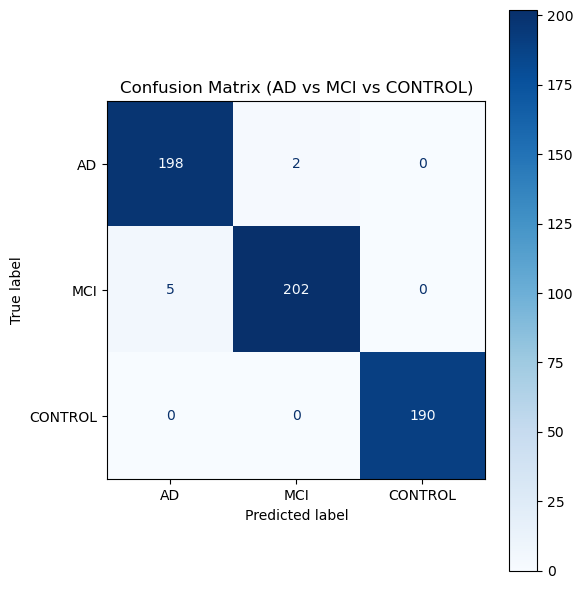

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# 클래스 순서를 명확히 지정 (예측 결과의 클래스 번호와 일치해야 함)
class_names = ["AD", "MCI", "CONTROL"]

# 1. Confusion Matrix 생성
cm = confusion_matrix(all_labels, all_preds)

# 2. Confusion Matrix 출력 및 시각화(예측값)
print("Confusion Matrix (AD vs MCI vs CONTROL):")
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap="Blues", ax=ax, values_format='d')
plt.title("Confusion Matrix (AD vs MCI vs CONTROL)")
plt.grid(False)
plt.tight_layout()
plt.savefig("confusion_matrix_3class.png")
plt.show()


In [28]:
import torch
import numpy as np

model.load_state_dict(torch.load("final_model.pt"))
model.eval()

risk_scores = []
true_labels = []
predicted_classes = []

# 클래스별 위험도 점수: CONTROL=2, MCI=6, AD=10
risk_weights = torch.tensor([2.0, 6.0, 10.0]).to(device)

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        
        outputs = model(X_batch)  # (batch_size, 3)
        probs = torch.softmax(outputs, dim=1)  # 확률값
        
        # 위험도 점수 = softmax 확률 * 가중치
        batch_risk = (probs * risk_weights).sum(dim=1)  # (batch_size,)
        risk_scores.extend(batch_risk.cpu().numpy())
        
        # 예측된 클래스 저장 (0:AD, 1:MCI, 2:CONTROL)
        preds = outputs.argmax(dim=1)
        predicted_classes.extend(preds.cpu().numpy())
        true_labels.extend(y_batch.cpu().numpy())


In [29]:
# 위험도, 예측 클래스, 실제 라벨을 함께 출력
for i in range(len(risk_scores)):
    print(f"Sample {i+1}: Risk Score = {risk_scores[i]:.2f}, "
          f"Predicted = {class_names[predicted_classes[i]]}, "
          f"True = {class_names[true_labels[i]]}")


Sample 1: Risk Score = 2.00, Predicted = AD, True = AD
Sample 2: Risk Score = 10.00, Predicted = CONTROL, True = CONTROL
Sample 3: Risk Score = 2.00, Predicted = AD, True = AD
Sample 4: Risk Score = 10.00, Predicted = CONTROL, True = CONTROL
Sample 5: Risk Score = 2.00, Predicted = AD, True = AD
Sample 6: Risk Score = 2.00, Predicted = AD, True = AD
Sample 7: Risk Score = 2.00, Predicted = AD, True = AD
Sample 8: Risk Score = 10.00, Predicted = CONTROL, True = CONTROL
Sample 9: Risk Score = 10.00, Predicted = CONTROL, True = CONTROL
Sample 10: Risk Score = 6.00, Predicted = MCI, True = MCI
Sample 11: Risk Score = 10.00, Predicted = CONTROL, True = CONTROL
Sample 12: Risk Score = 10.00, Predicted = CONTROL, True = CONTROL
Sample 13: Risk Score = 2.00, Predicted = AD, True = AD
Sample 14: Risk Score = 2.00, Predicted = AD, True = AD
Sample 15: Risk Score = 2.00, Predicted = AD, True = AD
Sample 16: Risk Score = 2.00, Predicted = AD, True = AD
Sample 17: Risk Score = 2.00, Predicted = AD,

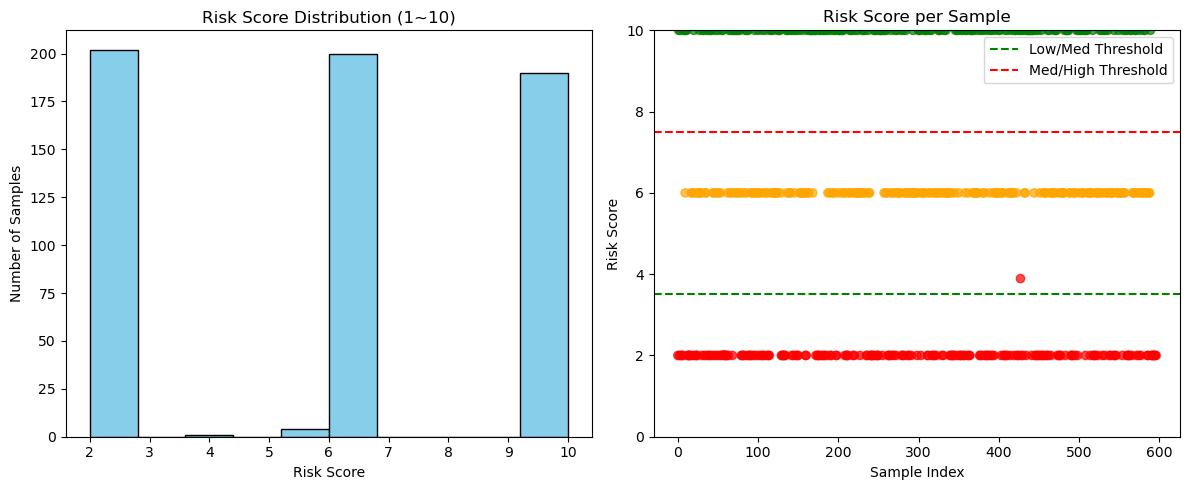

In [ ]:
# 1. 위험도 점수 시각화 (히스토그램 + 산점도)
import matplotlib.pyplot as plt

# 시각화용 라벨: class_names는 ["AD", "MCI", "CONTROL"]
colors = ["red" if pred == 0 else "orange" if pred == 1 else "green" for pred in predicted_classes]

plt.figure(figsize=(12, 5))

# 히스토그램
plt.subplot(1, 2, 1)
plt.hist(risk_scores, bins=10, color='skyblue', edgecolor='black')
plt.title("Risk Score Distribution (1~10)")
plt.xlabel("Risk Score")
plt.ylabel("Number of Samples")

# 산점도
plt.subplot(1, 2, 2)
plt.scatter(range(len(risk_scores)), risk_scores, c=colors, alpha=0.7)
plt.title("Risk Score per Sample")
plt.xlabel("Sample Index")
plt.ylabel("Risk Score")
plt.ylim(0, 10)
plt.axhline(y=3.5, color='green', linestyle='--', label='Low/Med Threshold')
plt.axhline(y=7.5, color='red', linestyle='--', label='Med/High Threshold')
plt.legend()

plt.tight_layout()
plt.savefig("risk_score_visualization.png")
plt.show()


In [36]:
df_results = pd.DataFrame({
    "Sample": range(1, len(risk_scores)+1),
    "True Label": [class_names[i] for i in true_labels],
    "Predicted Label": [class_names[i] for i in predicted_classes],
    "Risk Score": [round(score, 2) for score in risk_scores],
})

print(df_results)

     Sample True Label Predicted Label  Risk Score
0         1         AD              AD         2.0
1         2    CONTROL         CONTROL        10.0
2         3         AD              AD         2.0
3         4    CONTROL         CONTROL        10.0
4         5         AD              AD         2.0
..      ...        ...             ...         ...
592     593         AD              AD         2.0
593     594         AD              AD         2.0
594     595         AD              AD         2.0
595     596         AD              AD         2.0
596     597         AD              AD         2.0

[597 rows x 4 columns]
